# DTR trends — raw GCM vs QDMSD vs BCSD snapshot, South Africa

Compares diurnal temperature range (`dtr`) trends between three datasets, all at the
debiased-coarse (pre-downscaling, GCM-native-grid) resolution so the comparison is
apples-to-apples:

1. **raw** — the raw CESM2-WACCM model output for the same lineage as `qdmsd` below
   (scenario member `006`, historical member `001`), no bias correction applied.
2. **qdmsd** — the QDMSD run from
   `configs/qa/cesm2-waccm/cesm2-waccm-ssp245-tmx-std-southafrica.yaml`
   (CESM2-WACCM, SSP245, member `006`, South Africa + halo).
3. **bcsd_snapshot** — the BCSD snapshot baseline used in
   `docs/how-to/snapshot-comparison.ipynb` (same GCM/region, historical member `001`,
   ssp245 member `008`).

Patterned off `notebooks/pipeline-stage-debugger-analyze-trends.ipynb`'s raw/prod/qdm
comparison, with `dtr`-specific summary and NaN/inf checks up front. Note `qdmsd` and
`raw` share the exact same member lineage (`006`/`001`), while `bcsd_snapshot` uses a
different scenario member (`008`) — so `bcsd_snapshot` vs `qdmsd` differences can also
reflect member-to-member internal variability, not only the debiasing method.

In [1]:
import warnings

import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm.cache import ArtifactCache
from srm.cli import load_configs
from srm.downscaling_utils import get_experiment, get_historical_experiment, subset_space
from srm.lineage import resolve_member_lineage
from srm.utils import open_icechunk

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

warnings.filterwarnings("ignore", category=FutureWarning)

_proj_kw = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
_transform_kw = dict(transform=ccrs.PlateCarree()) if _HAS_CARTOPY else {}


def _add_coastlines(ax):
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

## Load qdmsd run

In [2]:
QDMSD_CONFIG_PATH = "../configs/qa/cesm2-waccm/cesm2-waccm-ssp245-tmx-std-southafrica.yaml"

configs, options = load_configs(QDMSD_CONFIG_PATH)

# The config lists a single variable ("dtr") and a single downscaling method ("QDMSD"),
# so this expands to exactly one config.
config = configs[0]
assert config.variable == "dtr", f"expected dtr, got {config.variable}"

cache = ArtifactCache.from_config(config, options)

hist_member = resolve_member_lineage(
    gcm=config.gcm,
    scenario=config.scenario,
    ensemble_member=config.ensemble_member,
    variable=config.variable,
).historical

qdmsd_hist_loc = cache.debiased_coarse_historical_loc(hist_member)
qdmsd_scenario_loc = cache.debiased_coarse_scenario_loc()

# `cache.branch` defaults to this kernel's installed srm package version, which only
# matches the branch the run actually wrote to if that version happens to match.
#
# The scratch/output store is keyed on (gcm, obs_dataset, subset_bounds), so it is
# shared across every run over this same GCM + South Africa extent -- not just this
# config -- and can carry many unrelated branches (other configs, other package
# versions, ad hoc test branches). Picking "the one non-main branch" is therefore not
# reliable; instead, use the same check `ArtifactCache.exists` uses: a commit's
# `message` equals the `group` it wrote, so the branch(es) that actually hold *both*
# the historical and scenario dtr artifacts for this exact config are identifiable
# directly rather than guessed from branch names.
_qdmsd_bucket, _qdmsd_prefix = (
    qdmsd_hist_loc.store_path.replace("s3://", "").rstrip("/").split("/", 1)
)
_qdmsd_repo = icechunk.Repository.open(
    icechunk.s3_storage(bucket=_qdmsd_bucket, prefix=_qdmsd_prefix, region="us-west-2")
)


def _branch_has_group(branch, group):
    return any(s.message == group for s in _qdmsd_repo.ancestry(branch=branch))


_qdmsd_candidates = []
for _branch in sorted(b for b in _qdmsd_repo.list_branches() if b != "main"):
    if _branch_has_group(_branch, qdmsd_hist_loc.group) and _branch_has_group(
        _branch, qdmsd_scenario_loc.group
    ):
        _tip = next(_qdmsd_repo.ancestry(branch=_branch))
        _qdmsd_candidates.append((_branch, _tip.written_at))

_qdmsd_candidates.sort(key=lambda item: item[1], reverse=True)
print("branches holding both dtr artifacts for this config (most recent tip first):")
for _branch, _written_at in _qdmsd_candidates:
    print(f"  {_branch!r}  (tip written {_written_at})")

assert _qdmsd_candidates, (
    "no branch holds both the historical and scenario dtr artifacts for this config "
    f"({qdmsd_hist_loc.group!r}, {qdmsd_scenario_loc.group!r}) -- has `bcsd run` "
    "finished for this config yet?"
)
# Defaults to the most recently written match; override manually below if you know a
# different one of the printed candidates is the run you actually want.
qdmsd_branch = _qdmsd_candidates[0][0]
print(f"using branch {qdmsd_branch!r}")

qdmsd_hist = open_icechunk(
    path=qdmsd_hist_loc.store_path, branch=qdmsd_branch, group=qdmsd_hist_loc.group
)["dtr"]
qdmsd_scenario = open_icechunk(
    path=qdmsd_scenario_loc.store_path, branch=qdmsd_branch, group=qdmsd_scenario_loc.group
)["dtr"]

qdmsd_debiased_coarse = xr.concat([qdmsd_hist, qdmsd_scenario], dim="time").sortby("time")
qdmsd_debiased_coarse

branches holding both dtr artifacts for this config (most recent tip first):
  'v0.12.0.post18'  (tip written 2026-08-25 16:57:50.171964+00:00)
using branch 'v0.12.0.post18'


<xarray.DataArray 'dtr' (time: 33238, lat: 20, lon: 18)> Size: 48MB
dask.array<getitem, shape=(33238, 20, 18), dtype=float32, chunksize=(365, 20, 18), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 266kB 1978-01-01 1978-01-02 ... 2068-12-31
  * lat      (lat) float64 160B -37.23 -36.28 -35.34 ... -21.2 -20.26 -19.32
  * lon      (lon) float64 144B 13.75 15.0 16.25 17.5 ... 31.25 32.5 33.75 35.0

## Load bcsd snapshot run

Uses the same store and branch as `snapshot_uri`/`snapshot_branch` in
`docs/how-to/snapshot-comparison.ipynb` — the `v0.12.0`-lineage BCSD baseline for
CESM2-WACCM / South Africa. `dtr`'s historical member (`001`) and ssp245 member (`008`)
are read straight from `srm.snapshot.baselines`-derived paths rather than through the
full `_open_output_datatree`/leaf-inventory machinery in that notebook, since this
notebook only needs the two `dtr` leaves, not a full candidate-vs-snapshot diff.

In [3]:
BCSD_SNAPSHOT_URI = (
    "s3://carbonplan-srm/scratch/snapshot/output/qa/"
    "CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk"
)
BCSD_SNAPSHOT_BRANCH = "main-51b4645-aug-24"
BCSD_HIST_MEMBER = "001"
BCSD_SCENARIO_MEMBER = "008"
BCSD_SCENARIO_GROUP = "ssp245"

bcsd_hist = open_icechunk(
    path=BCSD_SNAPSHOT_URI,
    branch=BCSD_SNAPSHOT_BRANCH,
    group=f"debiased_coarse/historical/dtr/{BCSD_HIST_MEMBER}",
)["dtr"]
bcsd_scenario = open_icechunk(
    path=BCSD_SNAPSHOT_URI,
    branch=BCSD_SNAPSHOT_BRANCH,
    group=f"debiased_coarse/{BCSD_SCENARIO_GROUP}/dtr/{BCSD_SCENARIO_MEMBER}",
)["dtr"]

bcsd_debiased_coarse = (
    xr.concat([bcsd_hist, bcsd_scenario], dim="time")
    .sortby("time")
    # Defensive: both stores cover the same South Africa + halo extent, but align to
    # qdmsd's exact grid rather than assuming it, since a silent grid mismatch would
    # otherwise show up as bogus differences downstream.
    .sel(
        lat=slice(qdmsd_debiased_coarse.lat.min(), qdmsd_debiased_coarse.lat.max()),
        lon=slice(qdmsd_debiased_coarse.lon.min(), qdmsd_debiased_coarse.lon.max()),
    )
)
bcsd_debiased_coarse

<xarray.DataArray 'dtr' (time: 33603, lat: 20, lon: 18)> Size: 48MB
dask.array<getitem, shape=(33603, 20, 18), dtype=float32, chunksize=(365, 20, 18), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 269kB 1978-01-01 1978-01-02 ... 2069-12-31
  * lat      (lat) float64 160B -37.23 -36.28 -35.34 ... -21.2 -20.26 -19.32
  * lon      (lon) float64 144B 13.75 15.0 16.25 17.5 ... 31.25 32.5 33.75 35.0

## Load raw GCM

Raw (undebiased) CESM2-WACCM output for the same lineage `qdmsd` uses — historical
member `001`, scenario member `006` — following the same load pattern as
`pipeline-stage-debugger-analyze-trends.ipynb`'s "Load raw GCM" cell. This sits on the
GCM's native grid, same as the `debiased_coarse` arrays above (debiasing doesn't change
the grid, only the later downscaling stage does), so it lines up with `qdmsd_debiased_coarse`
and `bcsd_debiased_coarse` without regridding.

In [4]:
raw_hist = subset_space(
    get_historical_experiment(gcm=config.gcm, member=hist_member, var=config.variable),
    coord_bounds_list=config.subset_bounds,
).sel(time=slice(str(config.train_period_start), str(config.train_period_end)))

raw_scenario = get_experiment(
    gcm=config.gcm,
    scenario=config.scenario,
    var=config.variable,
    ensemble_member=config.ensemble_member,
    coord_bounds_list=config.subset_bounds,
).sel(time=slice(str(config.predict_period_start), str(config.predict_period_end)))

raw_debiased_coarse = xr.concat([raw_hist, raw_scenario], dim="time").sortby("time")
raw_debiased_coarse

<xarray.DataArray 'dtr' (time: 33238, lat: 20, lon: 18)> Size: 48MB
dask.array<getitem, shape=(33238, 20, 18), dtype=float32, chunksize=(150, 20, 18), chunktype=numpy.ndarray>
Coordinates:
  * time             (time) datetime64[ns] 266kB 1978-01-01 ... 2068-12-31
    ensemble_member  (time) <U3 399kB '001' '001' '001' ... '006' '006' '006'
  * lat              (lat) float64 160B -37.23 -36.28 -35.34 ... -20.26 -19.32
  * lon              (lon) float64 144B 13.75 15.0 16.25 ... 32.5 33.75 35.0
  * spatial_ref      int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
Attributes:
    units:      K
    long_name:  Diurnal Temperature Range

In [5]:
datasets = {
    "raw": raw_debiased_coarse,
    "bcsd_snapshot": bcsd_debiased_coarse,
    "qdmsd": qdmsd_debiased_coarse,
}

HISTORICAL_PERIOD = slice("1985", "2014")
# qdmsd's member 006 ends 2068-12-31 (see the config's header comment), so the future
# window is a 30-year period ending there rather than the usual 2060-2090.
FUTURE_PERIOD = slice("2039", "2068")

for label, da in datasets.items():
    t = da["time"]
    assert t.max().values >= np.datetime64(f"{FUTURE_PERIOD.stop}-12-31"), (
        f"{label} only runs through {t.max().values}, short of "
        f"{FUTURE_PERIOD.stop}-12-31 needed for the future period"
    )
    assert t.min().values <= np.datetime64(f"{HISTORICAL_PERIOD.start}-01-01"), (
        f"{label} only starts at {t.min().values}, after "
        f"{HISTORICAL_PERIOD.start}-01-01 needed for the historical period"
    )

## Historical & future summary: mean, max, min DTR

Spatial maps of the three summary statistics in each period, one figure per dataset, so
the raw DTR climatology (not just the change in it) is visible before looking at trends
or differences between the two runs.

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


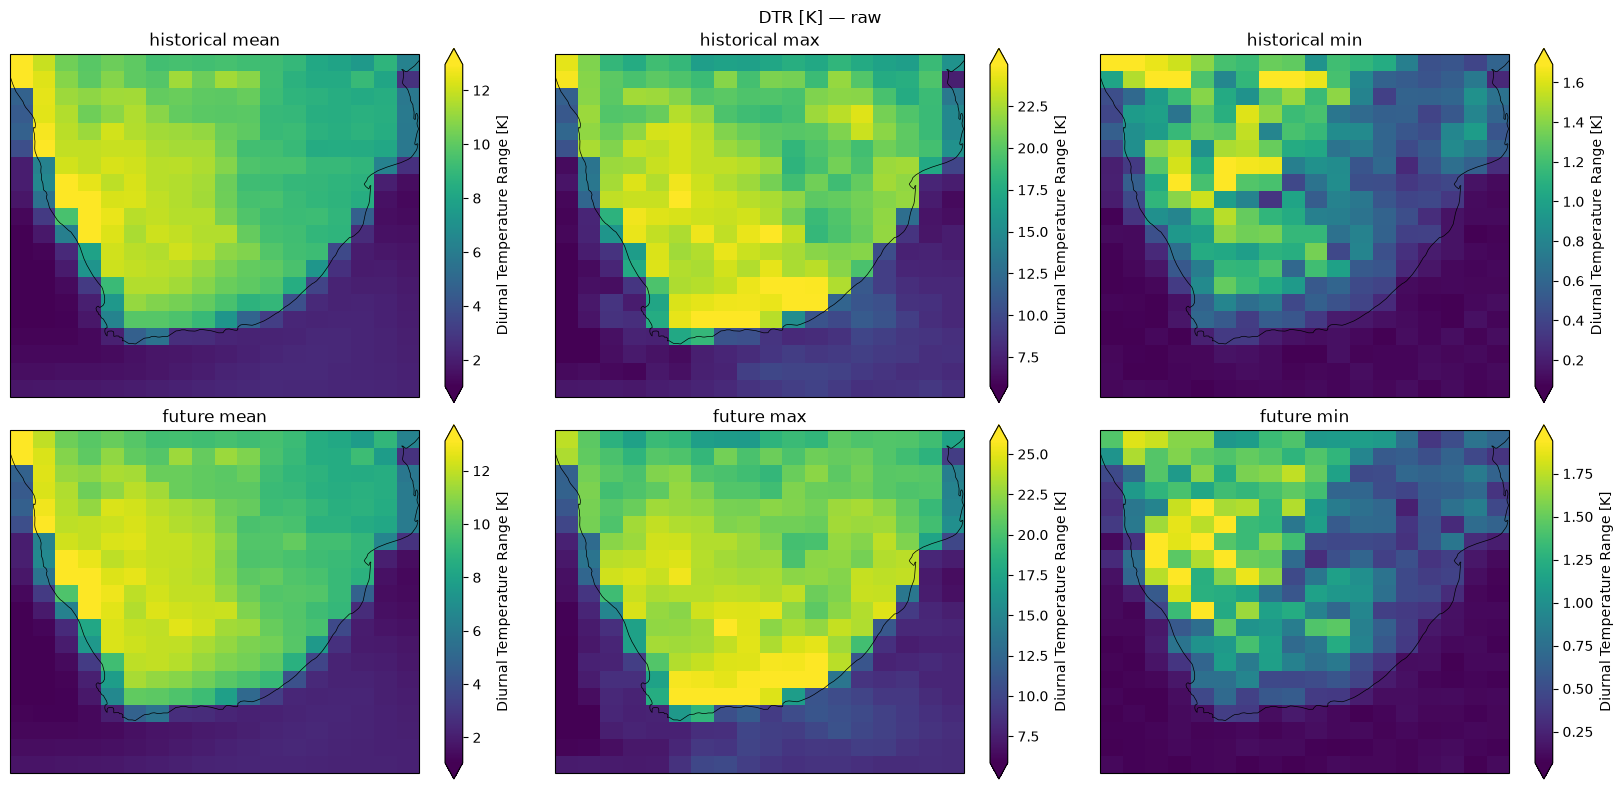

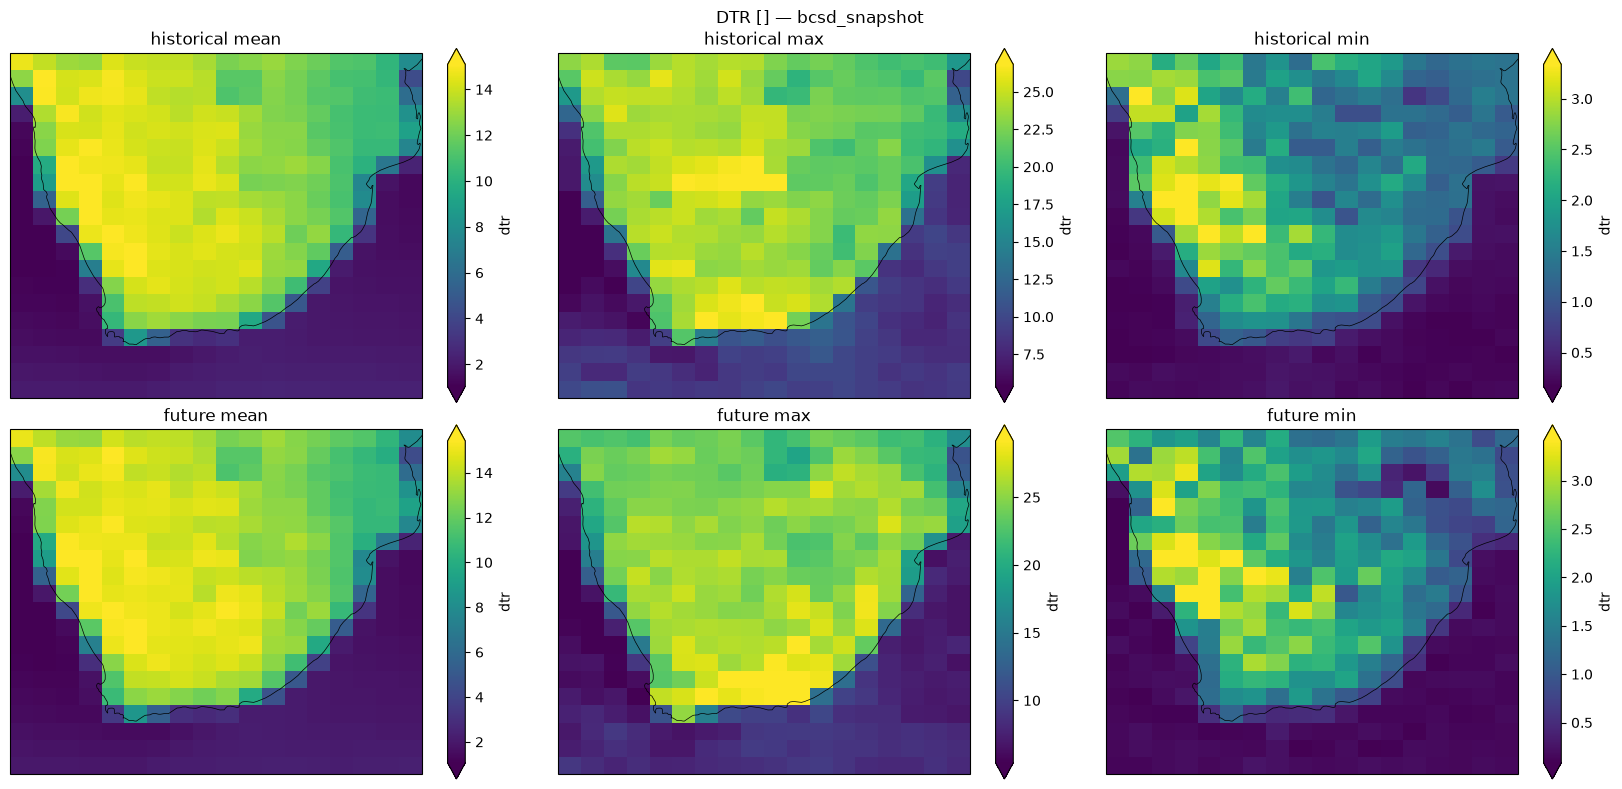

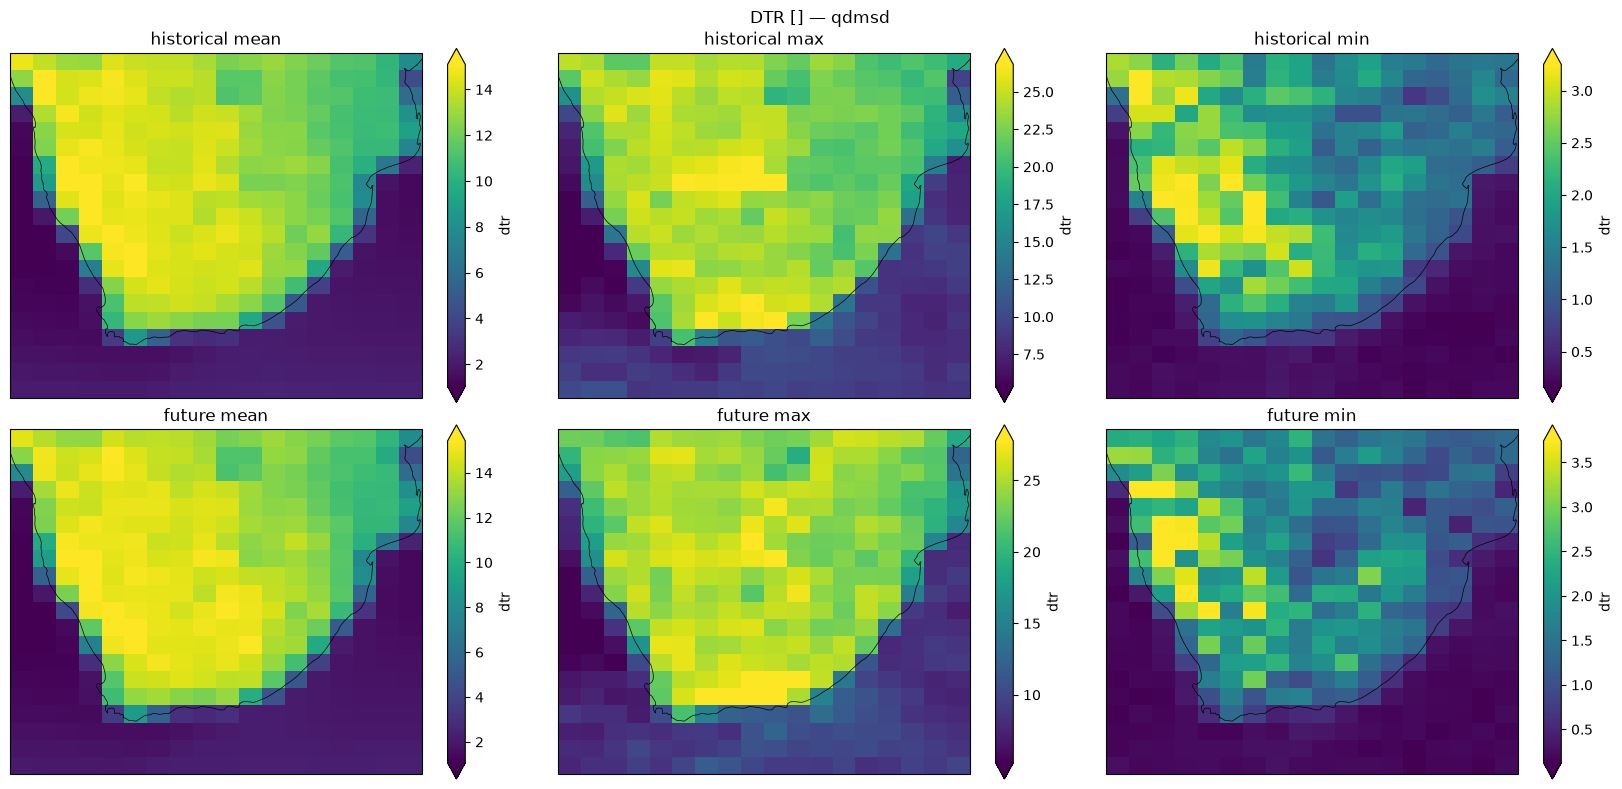

In [6]:
_STATS = {"mean": lambda x: x.mean("time"), "max": lambda x: x.max("time"), "min": lambda x: x.min("time")}
_PERIODS = {"historical": HISTORICAL_PERIOD, "future": FUTURE_PERIOD}


def plot_summary_maps(da, label):
    units = da.attrs.get("units", "")
    fig, axes = plt.subplots(
        len(_PERIODS), len(_STATS), figsize=(5.5 * len(_STATS), 4 * len(_PERIODS)), subplot_kw=_proj_kw
    )
    for i, (period_name, period) in enumerate(_PERIODS.items()):
        da_period = da.sel(time=period)
        for j, (stat_name, stat_fn) in enumerate(_STATS.items()):
            arr = stat_fn(da_period).compute()
            arr.plot(ax=axes[i, j], robust=True, cmap="viridis", **_transform_kw)
            _add_coastlines(axes[i, j])
            axes[i, j].set_title(f"{period_name} {stat_name}")
            axes[i, j].set_xlabel(None)
            axes[i, j].set_ylabel(None)
    fig.suptitle(f"DTR [{units}] — {label}")
    plt.tight_layout()
    plt.show()


for label, da in datasets.items():
    plot_summary_maps(da, label)

## NaN / inf check

In [7]:
for label, da in datasets.items():
    n_total = da.size
    n_nan = int(da.isnull().sum().compute())
    n_inf = int(xr.apply_ufunc(np.isinf, da, dask="parallelized").sum().compute())
    print(
        f"{label}: NaN {n_nan}/{n_total} ({n_nan / n_total:.4%}), "
        f"inf {n_inf}/{n_total} ({n_inf / n_total:.4%})"
    )

raw: NaN 0/11965680 (0.0000%), inf 0/11965680 (0.0000%)
bcsd_snapshot: NaN 0/12097080 (0.0000%), inf 0/12097080 (0.0000%)
qdmsd: NaN 0/11965680 (0.0000%), inf 0/11965680 (0.0000%)


## Climate-change trend maps (mean & 99th percentile)

`cc_delta` reduces each dataset to a historical-period statistic and a future-period
statistic and returns their difference; `relative_delta` expresses that difference as a
percentage of the historical value. For each metric, the figure below shows, per row:

- row 0 — `Δ raw`, `Δ bcsd_snapshot`, `Δ qdmsd` on their own
- row 1 — `Δ bcsd_snapshot - Δ raw` and `Δ qdmsd - Δ raw`: how much each debiasing
  approach shifts the raw model's trend
- row 2 — `Δ qdmsd - Δ bcsd_snapshot`: the two debiasing approaches against each other
  directly (interpret alongside the member-lineage caveat above — `qdmsd` is member
  `006`, `bcsd_snapshot` is member `008`)

In [8]:
def cc_delta(da, metric="mean"):
    """(future - historical) delta, plus the historical stat it was built from."""
    if metric == "mean":
        hist_stat = da.sel(time=HISTORICAL_PERIOD).mean("time")
        fut_stat = da.sel(time=FUTURE_PERIOD).mean("time")
    elif metric == "99p":
        hist_stat = da.sel(time=HISTORICAL_PERIOD).quantile(0.99, dim="time")
        fut_stat = da.sel(time=FUTURE_PERIOD).quantile(0.99, dim="time")
    else:
        raise ValueError(f"unknown metric: {metric}")
    return (fut_stat - hist_stat).compute(), hist_stat.compute()


def relative_delta(absolute_delta, hist_stat):
    return absolute_delta / hist_stat * 100


deltas = {}
for label, da in datasets.items():
    for metric in ["mean", "99p"]:
        delta, hist_stat = cc_delta(da, metric=metric)
        deltas[(label, metric)] = {
            "abs": delta,
            "hist": hist_stat,
            "rel": relative_delta(delta, hist_stat),
        }

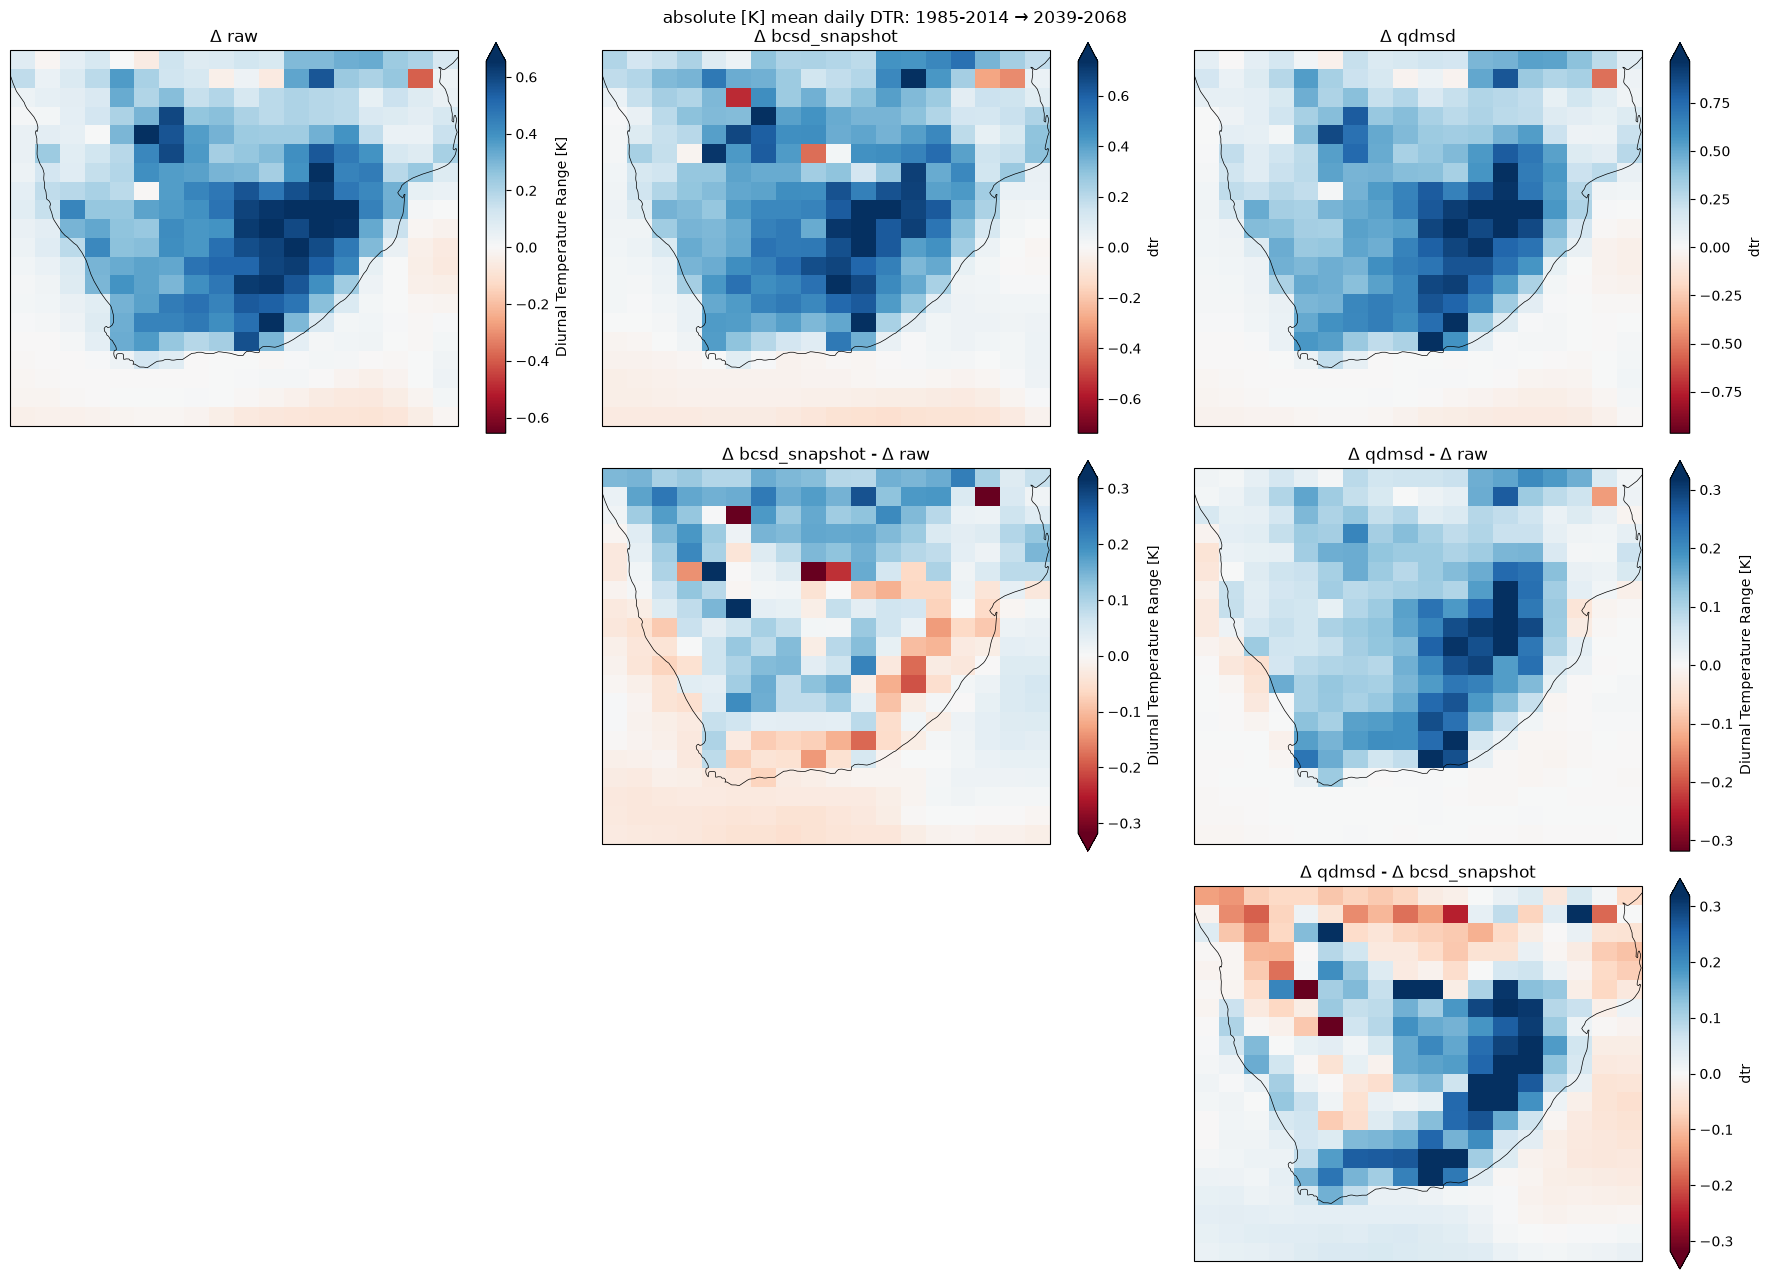

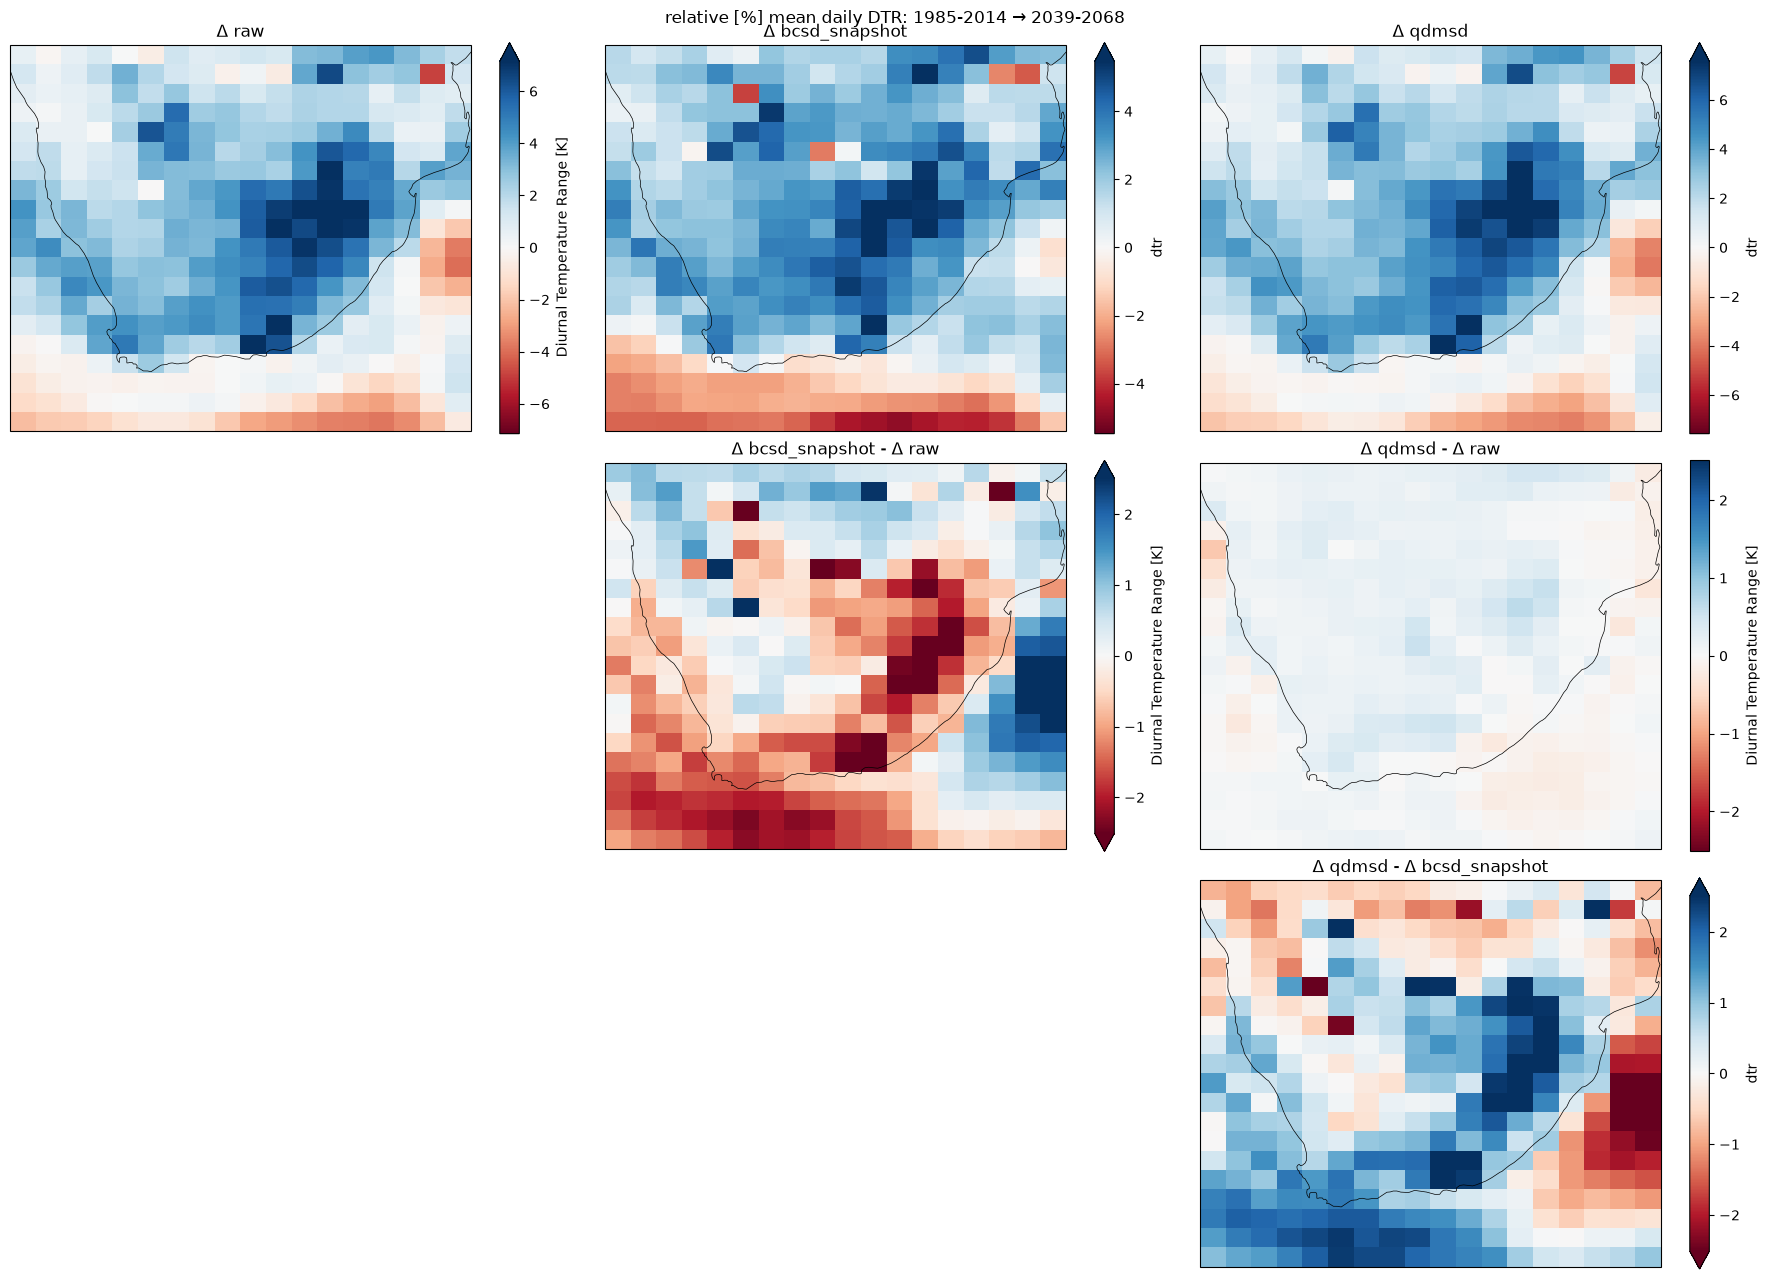

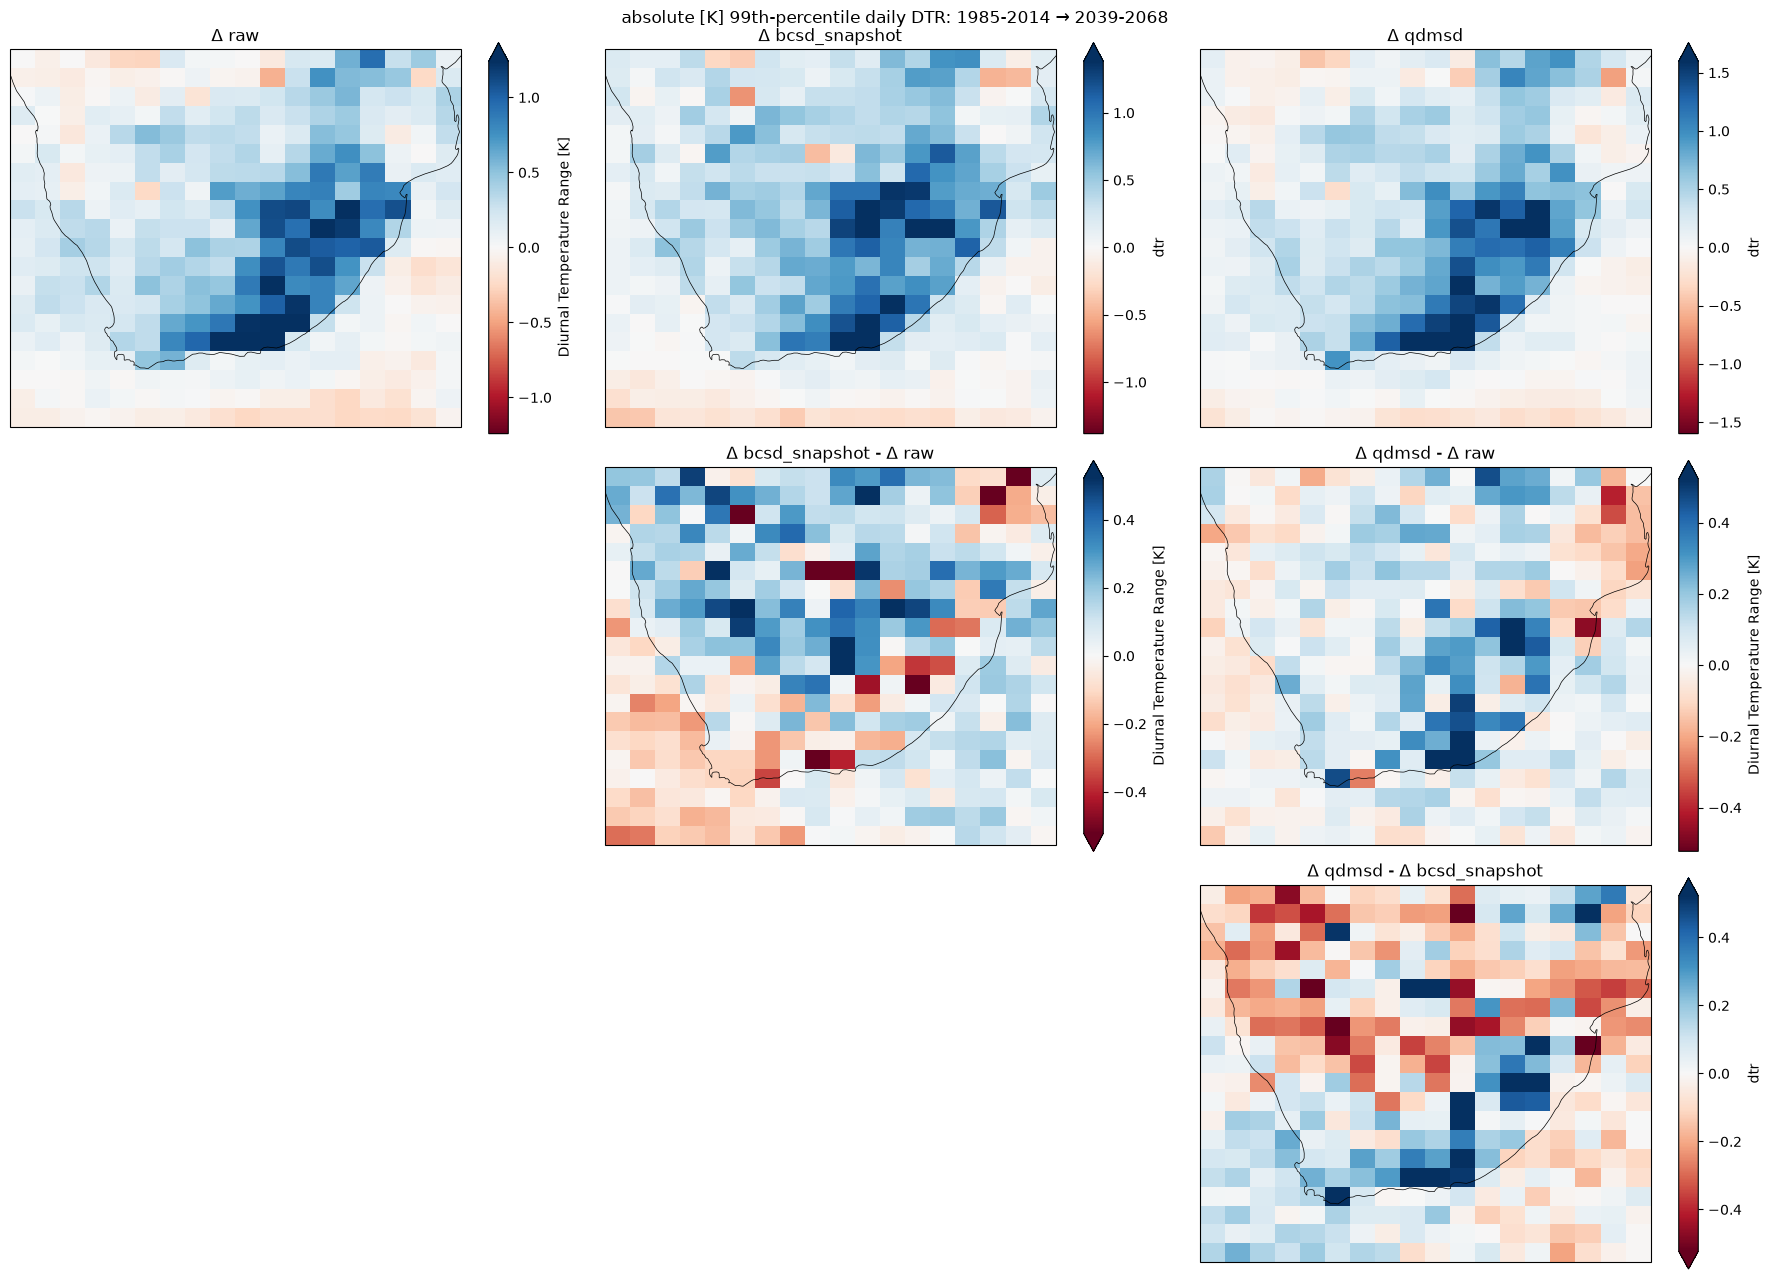

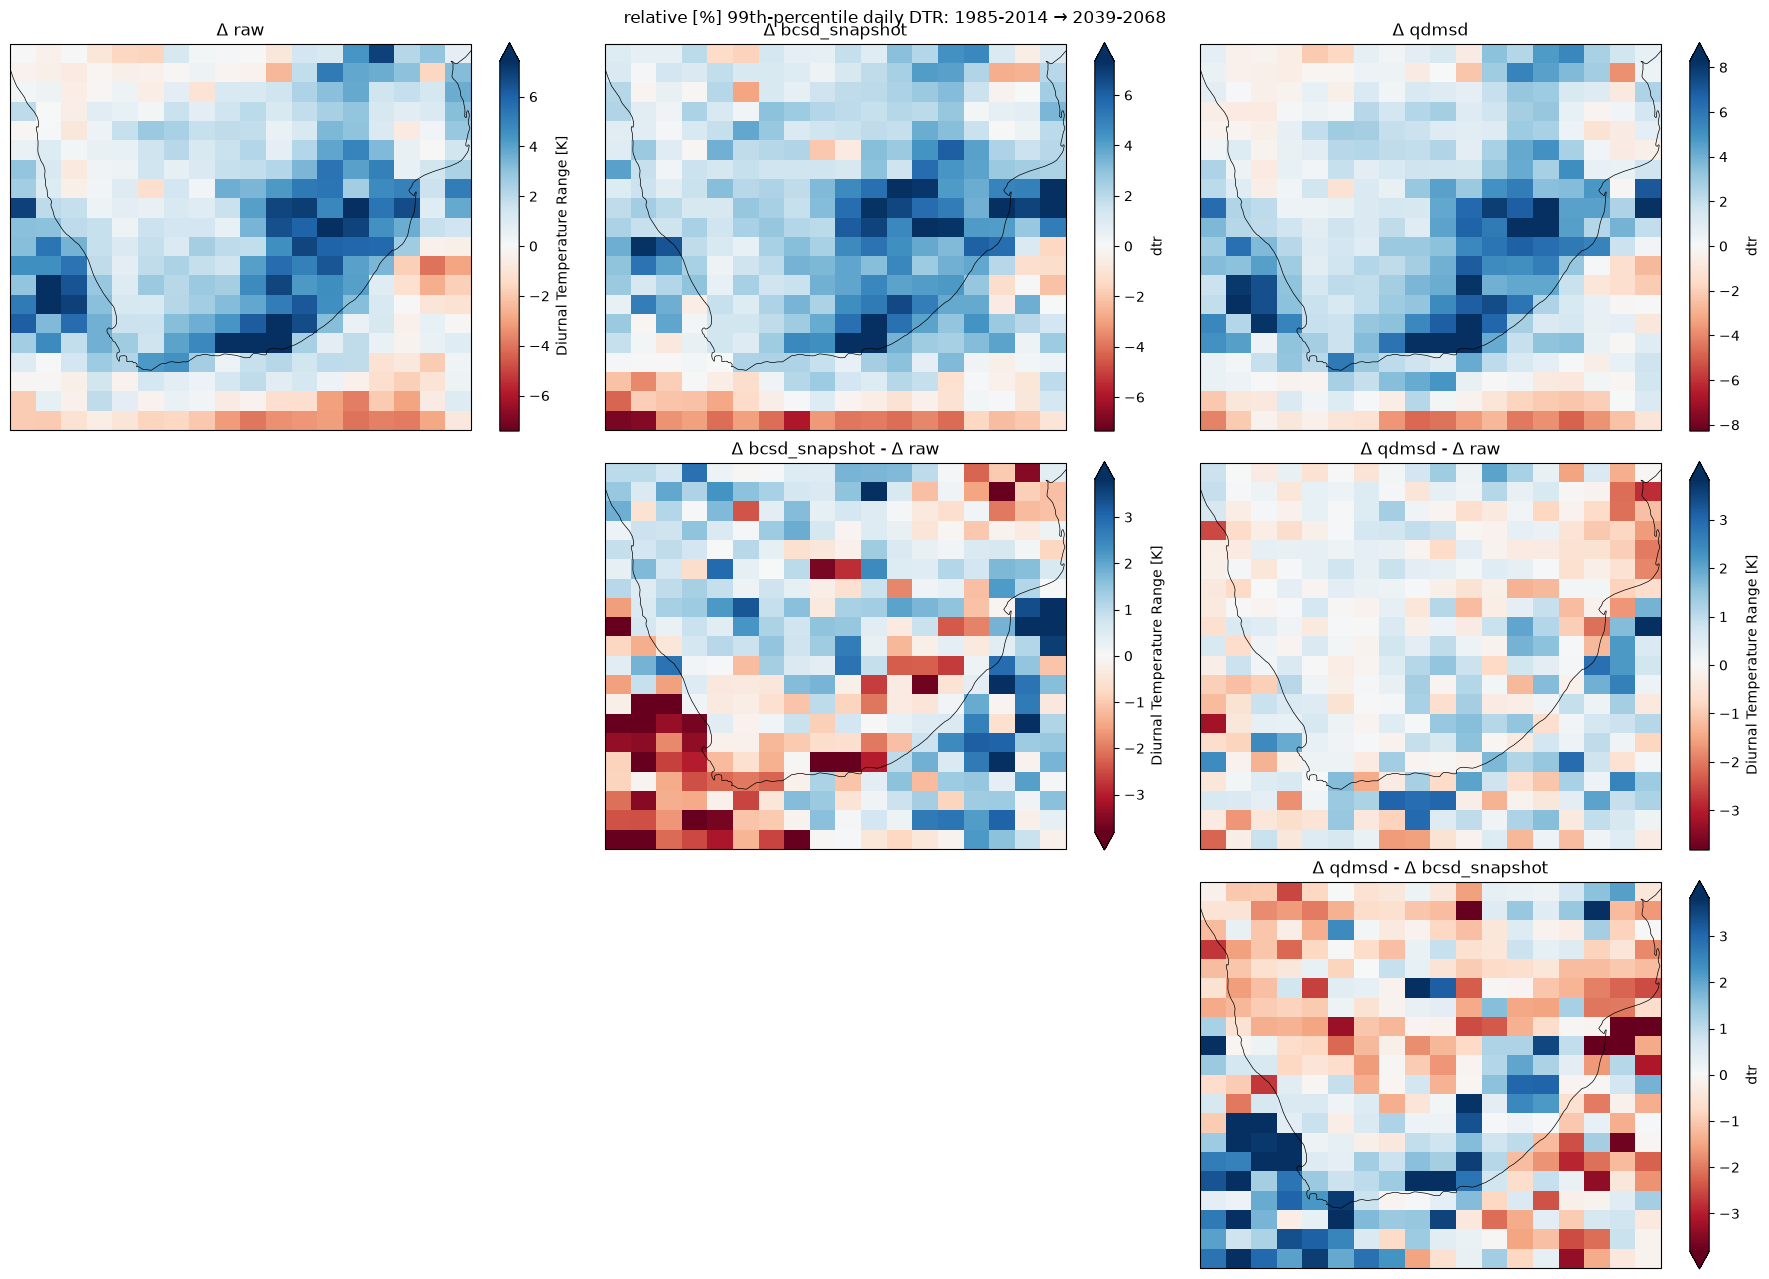

In [9]:
def _shared_robust_center0_limits(*das):
    """Symmetric-around-zero robust (2nd/98th percentile) limits pooled across arrays."""
    combined = np.concatenate([np.asarray(da.values).ravel() for da in das])
    combined = combined[np.isfinite(combined)]
    p2, p98 = np.nanpercentile(combined, [2, 98])
    vlim = max(abs(p2), abs(p98))
    return -vlim, vlim


_METRIC_LABELS = {"mean": "mean daily DTR", "99p": "99th-percentile daily DTR"}

for metric in ["mean", "99p"]:
    for method in ["abs", "rel"]:
        raw_val = deltas[("raw", metric)][method]
        bcsd_val = deltas[("bcsd_snapshot", metric)][method]
        qdmsd_val = deltas[("qdmsd", metric)][method]
        bcsd_minus_raw = bcsd_val - raw_val
        qdmsd_minus_raw = qdmsd_val - raw_val
        qdmsd_minus_bcsd = qdmsd_val - bcsd_val

        panels = {
            "Δ raw": [raw_val, (0, 0)],
            "Δ bcsd_snapshot": [bcsd_val, (0, 1)],
            "Δ qdmsd": [qdmsd_val, (0, 2)],
            "Δ bcsd_snapshot - Δ raw": [bcsd_minus_raw, (1, 1)],
            "Δ qdmsd - Δ raw": [qdmsd_minus_raw, (1, 2)],
            "Δ qdmsd - Δ bcsd_snapshot": [qdmsd_minus_bcsd, (2, 2)],
        }
        # Residual rows (1 and 2) share one symmetric color scale so their magnitudes
        # are directly comparable; row 0's raw deltas keep independent robust scaling.
        residual_vmin, residual_vmax = _shared_robust_center0_limits(
            bcsd_minus_raw, qdmsd_minus_raw, qdmsd_minus_bcsd
        )

        fig, axes = plt.subplots(3, 3, figsize=(18, 13), subplot_kw=_proj_kw)
        for title, (arr, (i, j)) in panels.items():
            plot_kwargs = (
                dict(vmin=residual_vmin, vmax=residual_vmax) if i > 0 else dict(robust=True)
            )
            arr.plot(ax=axes[i, j], cmap="RdBu", center=0, **plot_kwargs, **_transform_kw)
            _add_coastlines(axes[i, j])
            axes[i, j].set_title(title)
            axes[i, j].set_xlabel(None)
            axes[i, j].set_ylabel(None)
        # No "raw - raw" residual, and only one difference-of-deltas panel.
        axes[1, 0].set_axis_off()
        axes[2, 0].set_axis_off()
        axes[2, 1].set_axis_off()
        units_label = "absolute [K]" if method == "abs" else "relative [%]"
        fig.suptitle(
            f"{units_label} {_METRIC_LABELS[metric]}: "
            f"{HISTORICAL_PERIOD.start}-{HISTORICAL_PERIOD.stop} → "
            f"{FUTURE_PERIOD.start}-{FUTURE_PERIOD.stop}"
        )
        plt.tight_layout()
        plt.show()

## Per-pixel time series

Same focus point used in `pipeline-stage-debugger-analyze-trends.ipynb` (central South
Africa), to see what the map-level trend differences above look like in the underlying
daily values for all three datasets (`raw`, `bcsd_snapshot`, `qdmsd`).

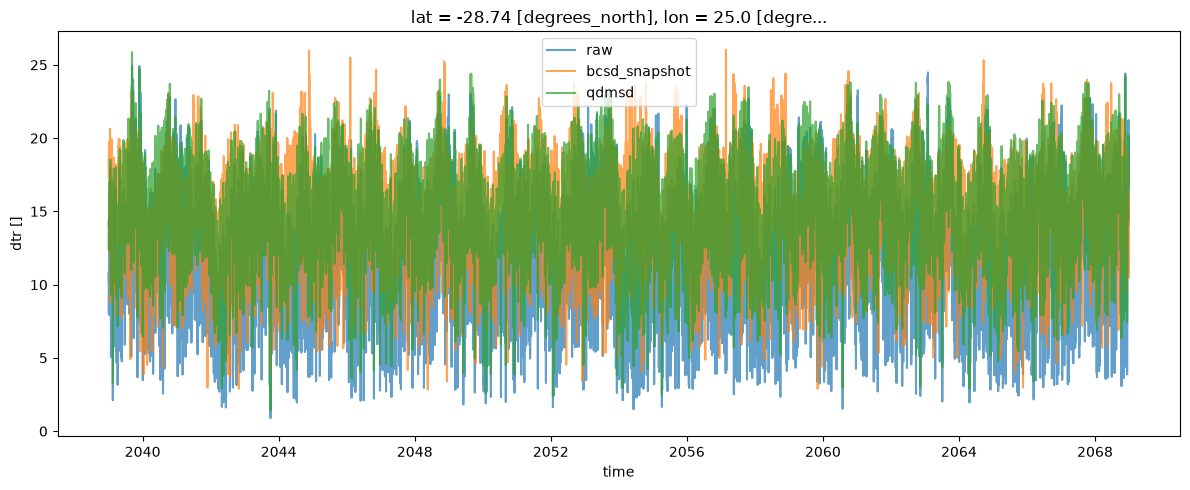

In [10]:
FOCUS_LAT, FOCUS_LON = -29.0, 25.0  # central South Africa

pt_dict = {
    label: da.sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(time=FUTURE_PERIOD).compute()
    for label, da in datasets.items()
}

fig, ax = plt.subplots(figsize=(12, 5))
for label, pt in pt_dict.items():
    pt.plot(ax=ax, label=label, alpha=0.7)
ax.set_ylabel(f"dtr [{qdmsd_debiased_coarse.attrs.get('units', '')}]")
ax.legend()
plt.tight_layout()
plt.show()

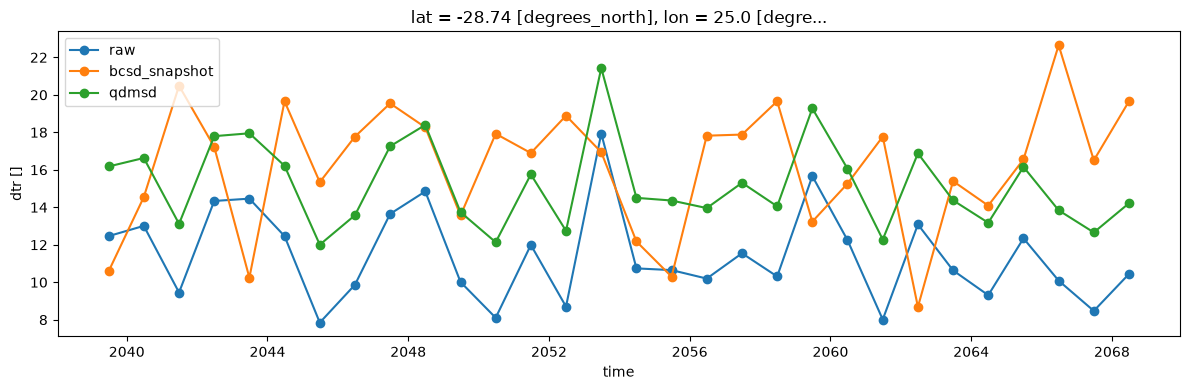

In [11]:
# Same point, only day-of-year 178 across all years — isolates one seasonal slice so
# the two runs' spread is easier to compare year to year.
fig, ax = plt.subplots(figsize=(12, 4))
for label, pt in pt_dict.items():
    pt.sel(time=pt.time.dt.dayofyear == 178).plot(ax=ax, label=label, marker="o")
ax.set_ylabel(f"dtr [{qdmsd_debiased_coarse.attrs.get('units', '')}]")
ax.legend()
plt.tight_layout()
plt.show()